In [2]:
import os
import shutil
import random
from pathlib import Path
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import cv2

In [3]:
PROJECT_ROOT = Path.cwd().parent

RAW_DATASET = PROJECT_ROOT / "raw_dataset"

CLEAR_DIR = RAW_DATASET / "clear"
IMPERFECTION_DIR = RAW_DATASET / "imperfection"

print("Project Root:", PROJECT_ROOT)
print("Raw Dataset:", RAW_DATASET)

Project Root: c:\Users\cadg0\Downloads\CSC173-DeepCV-Gumisad
Raw Dataset: c:\Users\cadg0\Downloads\CSC173-DeepCV-Gumisad\raw_dataset


In [4]:
assert CLEAR_DIR.exists(), f"Missing folder: {CLEAR_DIR}"
assert IMPERFECTION_DIR.exists(), f"Missing folder: {IMPERFECTION_DIR}"

print("Dataset folders found.")

Dataset folders found.


In [5]:
VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

clear_images = [
    f for f in CLEAR_DIR.iterdir()
    if f.suffix.lower() in VALID_EXTENSIONS
]

imperfection_images = [
    f for f in IMPERFECTION_DIR.iterdir()
    if f.suffix.lower() in VALID_EXTENSIONS
]

print(f"Clear Images: {len(clear_images)}")
print(f"Imperfection Images: {len(imperfection_images)}")
print(f"Total Images: {len(clear_images) + len(imperfection_images)}")

Clear Images: 1000
Imperfection Images: 1000
Total Images: 2000


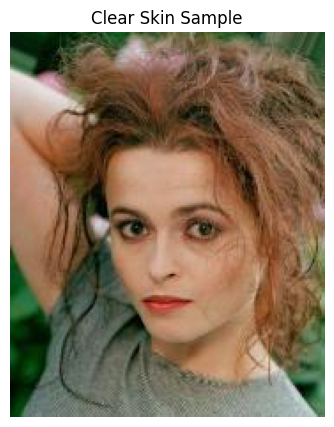

In [6]:
sample = random.choice(clear_images)

img = cv2.imread(str(sample))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title("Clear Skin Sample")
plt.axis("off")
plt.show()

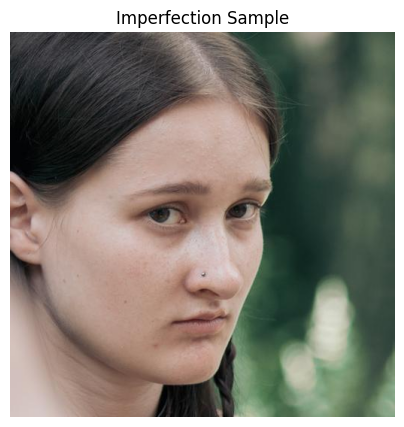

In [7]:
sample = random.choice(imperfection_images)

img = cv2.imread(str(sample))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title("Imperfection Sample")
plt.axis("off")
plt.show()

In [8]:
train_clear, temp_clear = train_test_split(
    clear_images,
    test_size=0.30,
    random_state=42
)

val_clear, test_clear = train_test_split(
    temp_clear,
    test_size=0.50,
    random_state=42
)

train_imp, temp_imp = train_test_split(
    imperfection_images,
    test_size=0.30,
    random_state=42
)

val_imp, test_imp = train_test_split(
    temp_imp,
    test_size=0.50,
    random_state=42
)

In [9]:
print("TRAIN")
print("Clear:", len(train_clear))
print("Imperfection:", len(train_imp))

print("\nVALIDATION")
print("Clear:", len(val_clear))
print("Imperfection:", len(val_imp))

print("\nTEST")
print("Clear:", len(test_clear))
print("Imperfection:", len(test_imp))

TRAIN
Clear: 700
Imperfection: 700

VALIDATION
Clear: 150
Imperfection: 150

TEST
Clear: 150
Imperfection: 150


In [10]:
DATASET_DIR = PROJECT_ROOT / "dataset"

folders = [
    DATASET_DIR / "train" / "clear",
    DATASET_DIR / "train" / "imperfection",
    DATASET_DIR / "val" / "clear",
    DATASET_DIR / "val" / "imperfection",
    DATASET_DIR / "test" / "clear",
    DATASET_DIR / "test" / "imperfection",
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

print("Dataset folders created.")

Dataset folders created.


In [11]:
def copy_files(files, destination):
    for file in files:
        shutil.copy(file, destination)

copy_files(train_clear, DATASET_DIR / "train" / "clear")
copy_files(train_imp, DATASET_DIR / "train" / "imperfection")

copy_files(val_clear, DATASET_DIR / "val" / "clear")
copy_files(val_imp, DATASET_DIR / "val" / "imperfection")

copy_files(test_clear, DATASET_DIR / "test" / "clear")
copy_files(test_imp, DATASET_DIR / "test" / "imperfection")

print("Dataset split completed.")

Dataset split completed.


In [12]:
for split in ["train", "val", "test"]:
    clear_count = len(list((DATASET_DIR / split / "clear").glob("*")))
    imp_count = len(list((DATASET_DIR / split / "imperfection").glob("*")))

    print(f"{split.upper()}")
    print(f"  Clear: {clear_count}")
    print(f"  Imperfection: {imp_count}")

TRAIN
  Clear: 700
  Imperfection: 700
VAL
  Clear: 150
  Imperfection: 150
TEST
  Clear: 150
  Imperfection: 150
